## IMPORTS

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os
import joblib

## CONSTANTS

In [3]:
NUMERICAL_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

CATEGORICAL_COLS = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

TARGET_COL = 'target'

## Step 1.1 — Load Dataset

In [4]:
def load_dataset(input_path: str) -> pd.DataFrame:
    df = pd.read_csv(input_path)
    print(f"  Original shape : {df.shape}")
    print(f"  Columns        : {list(df.columns)}")
    return df

## Step 1.2 — Save Raw Backup

In [5]:
def save_raw_backup(df: pd.DataFrame, raw_path: str) -> None:
    os.makedirs(os.path.dirname(raw_path), exist_ok=True)
    df.to_csv(raw_path, index=False)
    print(f"  Raw backup saved to: {raw_path}")

## Step 1.3 — Handle Missing Values

In [6]:
def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    print("\nHandling missing values")

    for col in NUMERICAL_COLS:
        if col in df.columns and df[col].isnull().sum() > 0:
            mean_val = df[col].mean()
            df[col] = df[col].fillna(mean_val)
            print(f"  Filled '{col}' with mean ({mean_val:.2f})")

    for col in CATEGORICAL_COLS:
        if col in df.columns and df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"  Filled '{col}' with mode ({mode_val})")

    return df

## Step 1.4 — Normalize Numerical Features

In [7]:
def normalize_features(df: pd.DataFrame, scaler_path: str) -> pd.DataFrame:
    print("\nNormalizing numerical features...")

    existing_num_cols = [col for col in NUMERICAL_COLS if col in df.columns]

    scaler = MinMaxScaler()
    df[existing_num_cols] = scaler.fit_transform(df[existing_num_cols])

    os.makedirs(os.path.dirname(scaler_path), exist_ok=True)
    joblib.dump(scaler, scaler_path)

    print(f"  Scaled columns : {existing_num_cols}")
    print(f"  Scaler saved to: {scaler_path}")

    return df

## Step 1.5 — Encode Categorical Variables

In [8]:
def encode_categorical(df: pd.DataFrame) -> pd.DataFrame:
    print("\nEncoding categorical variables...")

    existing_cat_cols = [col for col in CATEGORICAL_COLS if col in df.columns]
    df = pd.get_dummies(df, columns=existing_cat_cols, drop_first=True)

    print(f"  Encoded columns : {existing_cat_cols}")
    print(f"  New shape       : {df.shape}")

    return df

## Step 1.6 — Feature Selection

In [9]:
def select_features(df: pd.DataFrame, corr_threshold: float = 0.05) -> pd.DataFrame:
    print("\nPerforming feature selection (correlation)")

    corr = df.corr(numeric_only=True)[TARGET_COL].abs().sort_values(ascending=False)

    print("\n  Top 10 features correlated with target:")
    print(corr.head(11).to_string())

    important_features = corr[corr > corr_threshold].index.tolist()
    df = df[important_features]

    print(f"\n  Kept {len(important_features)} features (threshold = {corr_threshold})")

    return df

## Step 1.7 — Save Cleaned Dataset

In [10]:
def save_cleaned_data(df: pd.DataFrame, output_path: str) -> None:
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f"\n  Cleaned dataset saved to: {output_path}")
    print(f"  Final shape: {df.shape}")

## Main

In [11]:
def process_heart_disease_data(
    input_path: str = "heart.csv",
    raw_path: str = "data/raw_data.csv",
    output_path: str = "data/cleaned_data.csv",
    scaler_path: str = "data/scaler.pkl",
    corr_threshold: float = 0.05
) -> pd.DataFrame:

    df = load_dataset(input_path)
    save_raw_backup(df, raw_path)
    df = handle_missing_values(df)
    df = normalize_features(df, scaler_path)
    df = encode_categorical(df)
    df = select_features(df, corr_threshold)
    save_cleaned_data(df, output_path)

    return df

## DATA VISUALIZATION

## — Imports

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("reports", exist_ok=True)

DATA_PATH = "data/cleaned_data.csv"
TARGET_COL = "target"

## — Load Data

In [16]:
df = pd.read_csv(r"C:\ANU\Intellegent Programming\Heart_Diease_Detection\data\cleaned_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (304, 22)


,thal_2,thal_3,exang_1,thalach,oldpeak,cp_2,sex_1,slope_2,slope_1,ca_2,...,ca_1,age,restecg_1.0,cp_3,trestbps,chol,ca_4,thal_1,fbs_1,target
0,0,1,0,0.740458,0.161290,0,1,1,0,1,...,0,0.479167,1,0,0.316327,0.196347,0,0,0,0
1,0,1,1,0.641221,0.500000,0,1,0,0,0,...,0,0.500000,0,0,0.469388,0.175799,0,0,1,0
2,0,1,1,0.412214,0.419355,0,1,0,0,0,...,0,0.854167,1,0,0.520408,0.109589,0,0,0,0
3,0,1,0,0.687023,0.000000,0,1,1,0,0,...,1,0.666667,1,0,0.551020,0.175799,0,0,0,0
4,1,0,0,0.267176,0.306452,0,0,0,1,0,...,0,0.687500,1,0,0.448980,0.383562,0,0,1,0


## — Statistical Summary

In [ ]:
df.describe()

,target,oldpeak,thalach,age,trestbps,chol
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,0.513171,0.172910,0.596291,0.529878,0.354827,0.273973
std,0.500070,0.189493,0.175616,0.189006,0.165252,0.117791
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.465649,0.395833,0.245283,0.194064
50%,1.000000,0.129032,0.618321,0.562500,0.339623,0.260274
75%,1.000000,0.290323,0.725191,0.666667,0.433962,0.340183
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## — Correlation Heatmap

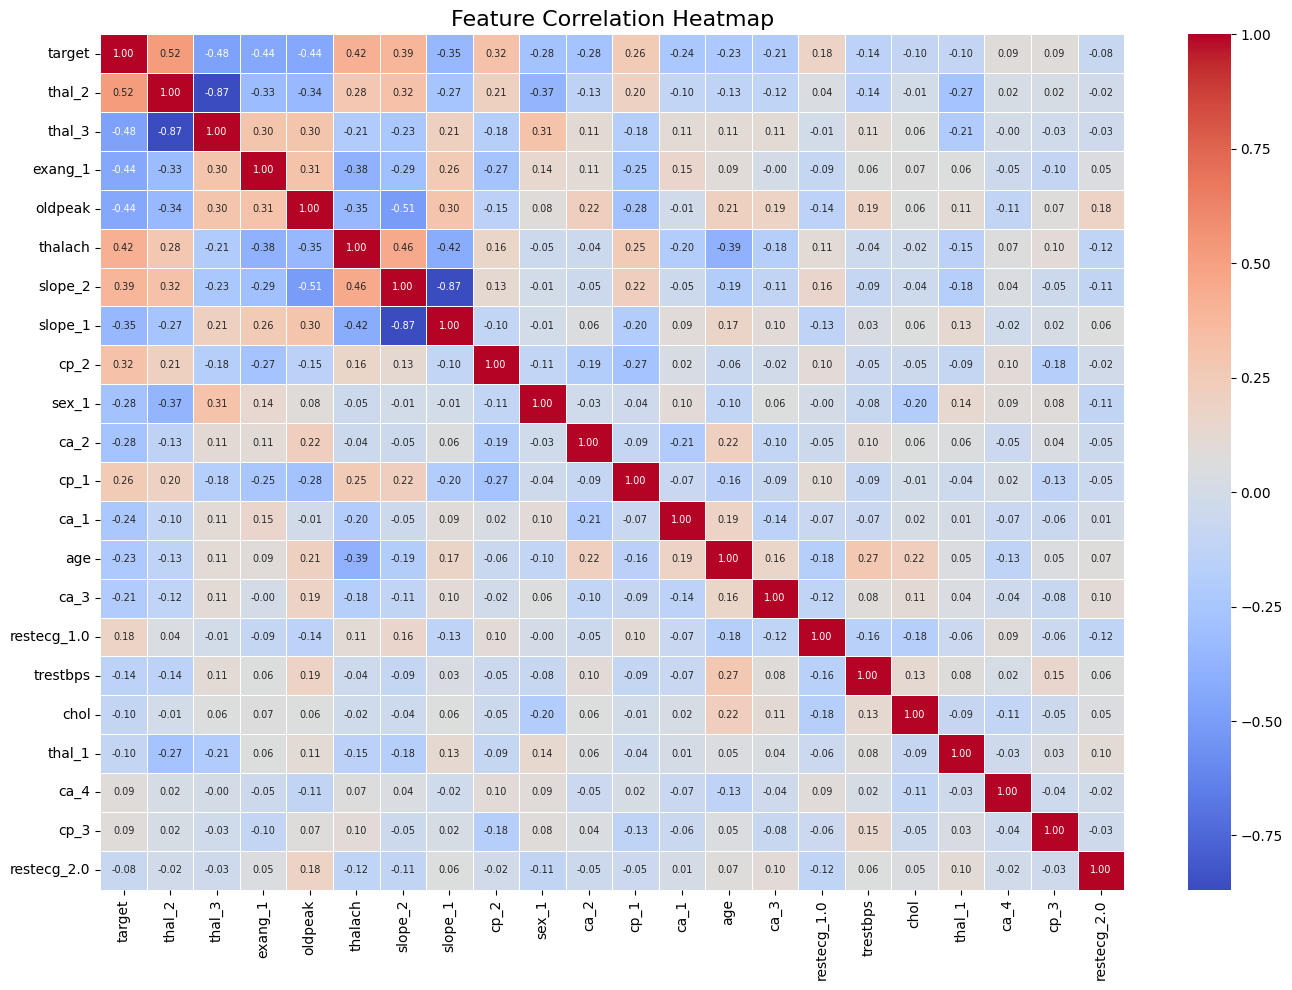

In [ ]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.savefig("reports/correlation_heatmap.png")
plt.show()

## — Histograms

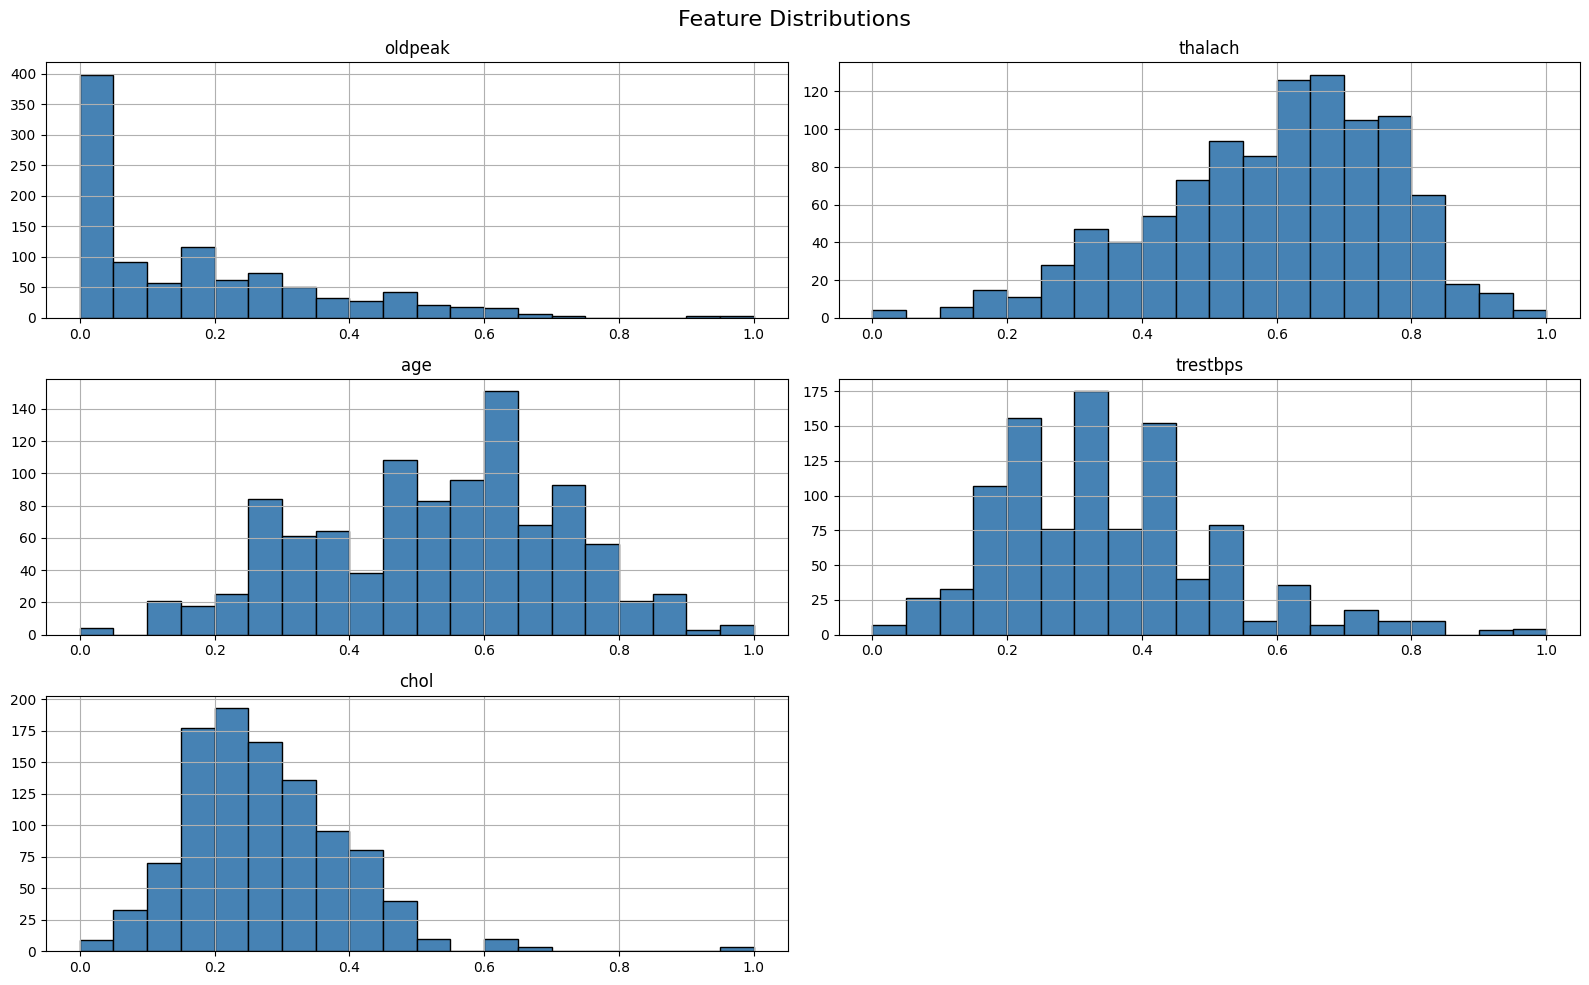

In [ ]:
numerical_cols = df.select_dtypes(include="number").columns.tolist()
numerical_cols = [col for col in numerical_cols if col != TARGET_COL]

df[numerical_cols].hist(
    bins=20,
    figsize=(16, 10),
    color="steelblue",
    edgecolor="black"
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.savefig("reports/histograms.png")
plt.show()

## — Boxplots

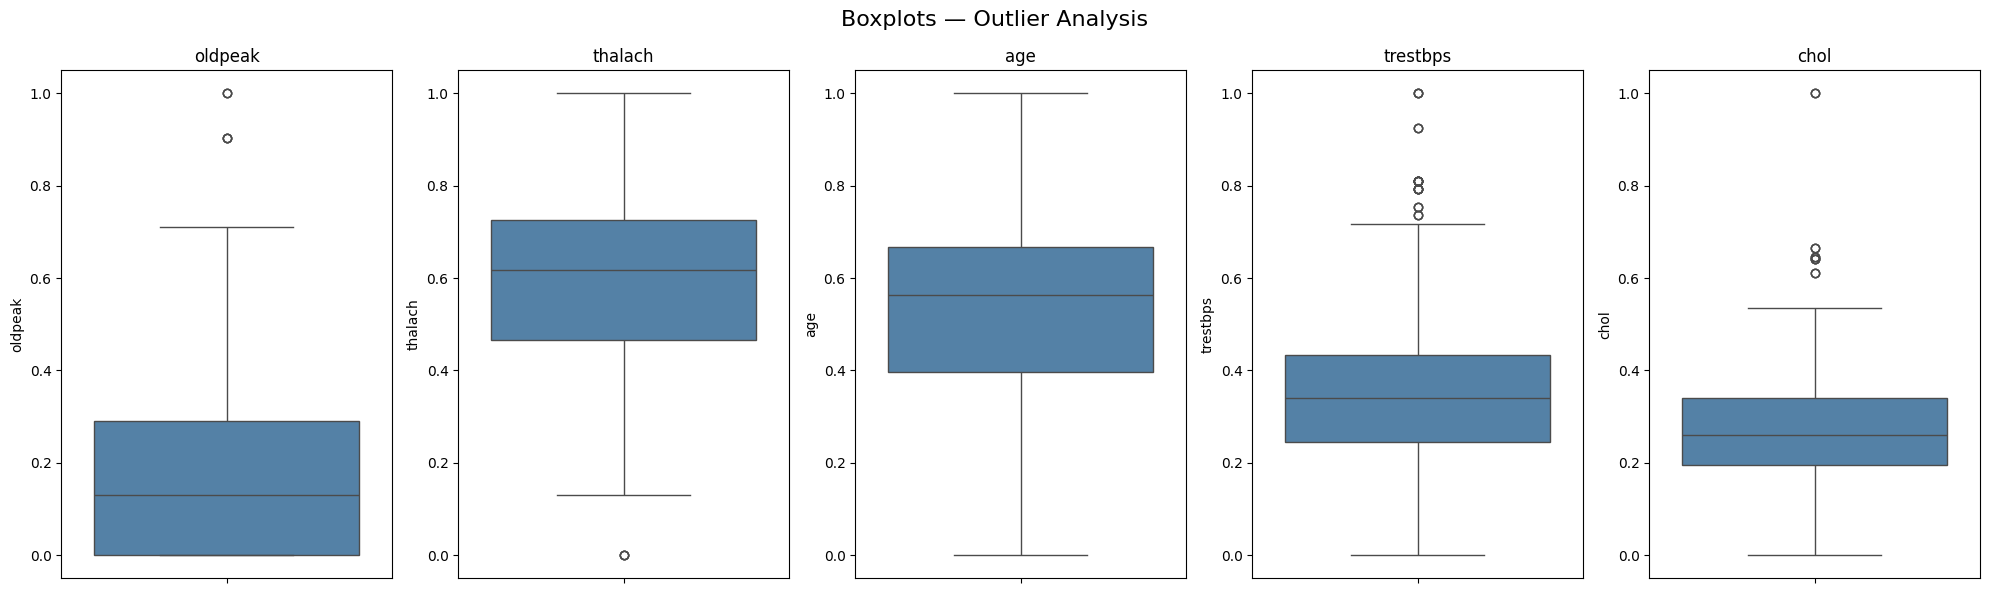

In [ ]:
n = len(numerical_cols)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 6))

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(col, fontsize=12)

plt.suptitle("Boxplots — Outlier Analysis", fontsize=16)
plt.tight_layout()
plt.savefig("reports/boxplots.png")
plt.show()

## — Feature Importance

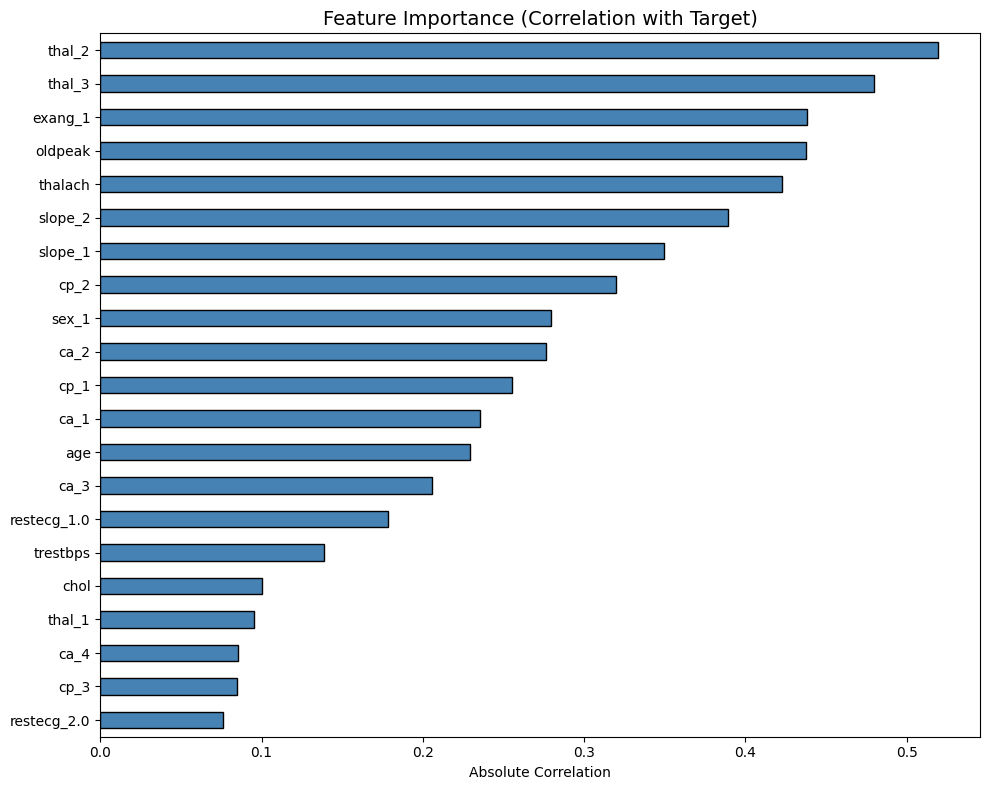

In [ ]:
corr = df.corr(numeric_only=True)[TARGET_COL].abs()
corr = corr.drop(labels=[TARGET_COL], errors="ignore")
corr = corr.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
corr.plot(
    kind="barh",
    color="steelblue",
    edgecolor="black"
)

plt.title("Feature Importance (Correlation with Target)", fontsize=14)
plt.xlabel("Absolute Correlation")
plt.tight_layout()
plt.savefig("reports/feature_importance.png")
plt.show()

In [22]:
n = len(df)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 6))

for i, col in enumerate(df):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(col, fontsize=12)

plt.suptitle("Boxplots — Outlier Analysis", fontsize=16)
plt.tight_layout()
plt.savefig("reports/boxplots.png")
plt.show()